# 05 Customer Clustering Analysis

This notebook adds an additional **Stage 4 unsupervised customer segmentation** analysis using KMeans. It does not replace Stage 5 classification models (DTC/SVM).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Paths and Output Directory

In [2]:
base_dir = Path.cwd()
results_dir = base_dir / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

train_dir = base_dir / 'train'
test_dir = base_dir / 'test'

print(f'Base directory: {base_dir}')
print(f'Results directory: {results_dir}')

Base directory: c:\Users\yazee\OneDrive\Desktop\ML_Proj
Results directory: c:\Users\yazee\OneDrive\Desktop\ML_Proj\results


## 3. Load Train/Test Features and Targets

The code supports both uppercase and lowercase file names for feature matrices (`X_train.csv`/`x_train.csv` and `X_test.csv`/`x_test.csv`).

In [3]:
def resolve_file(*candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('None of the candidate files were found: ' + ', '.join(str(c) for c in candidates))

X_train_path = resolve_file(train_dir / 'X_train.csv', train_dir / 'x_train.csv')
X_test_path = resolve_file(test_dir / 'X_test.csv', test_dir / 'x_test.csv')
y_train_path = resolve_file(train_dir / 'y_train.csv')
y_test_path = resolve_file(test_dir / 'y_test.csv')

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
y_train_df = pd.read_csv(y_train_path)
y_test_df = pd.read_csv(y_test_path)

if y_train_df.shape[1] == 1:
    y_train = y_train_df.iloc[:, 0]
else:
    y_train = y_train_df.squeeze()

if y_test_df.shape[1] == 1:
    y_test = y_test_df.iloc[:, 0]
else:
    y_test = y_test_df.squeeze()

print('Loaded files:')
print(f'- {X_train_path.name}: {X_train.shape}')
print(f'- {X_test_path.name}: {X_test.shape}')
print(f'- {y_train_path.name}: {y_train.shape}')
print(f'- {y_test_path.name}: {y_test.shape}')

Loaded files:
- X_train.csv: (4930, 30)
- X_test.csv: (2113, 30)
- y_train.csv: (4930,)
- y_test.csv: (2113,)


## 4. Combine Train and Test Data

In [4]:
X = pd.concat([X_train, X_test], axis=0, ignore_index=True)
y = pd.concat([y_train, y_test], axis=0, ignore_index=True)

print(f'Combined X shape: {X.shape}')
print(f'Combined y shape: {y.shape}')

Combined X shape: (7043, 30)
Combined y shape: (7043,)


## 5. Why Clustering Here?

Clustering is an **unsupervised learning** method. It does **not use the target label** during training.

In this project, clustering is used to discover natural customer segments from feature patterns. After clusters are formed, we compare clusters with churn labels **only for interpretation** (for example, identifying segments with higher churn rates).

## 6. Feature Scaling Before KMeans

KMeans is a **distance-based** algorithm. Scaling is important because features with larger numeric ranges can dominate distance calculations and bias cluster assignments.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled feature matrix shape:', X_scaled.shape)

Scaled feature matrix shape: (7043, 30)


## 7. Evaluate Number of Clusters (k=2..8)

In [7]:
evaluation_rows = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = km.fit_predict(X_scaled)

    inertia = km.inertia_
    sil = silhouette_score(X_scaled, cluster_labels)

    evaluation_rows.append({
        'k': k,
        'inertia': inertia,
        'silhouette_score': sil
    })

cluster_eval_df = pd.DataFrame(evaluation_rows)
cluster_eval_df

,k,inertia,silhouette_score
0,2,145801.857948,0.334954
1,3,126947.422183,0.218842
2,4,112099.581574,0.239022
3,5,106769.579275,0.192892
4,6,101756.847821,0.193740
5,7,98733.852329,0.189143
6,8,96912.101359,0.184991


In [8]:
cluster_eval_csv = results_dir / 'kmeans_cluster_evaluation.csv'
cluster_eval_df.to_csv(cluster_eval_csv, index=False)
print(f'Saved: {cluster_eval_csv}')

Saved: c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\kmeans_cluster_evaluation.csv


## 8. Elbow Method and Silhouette Plots

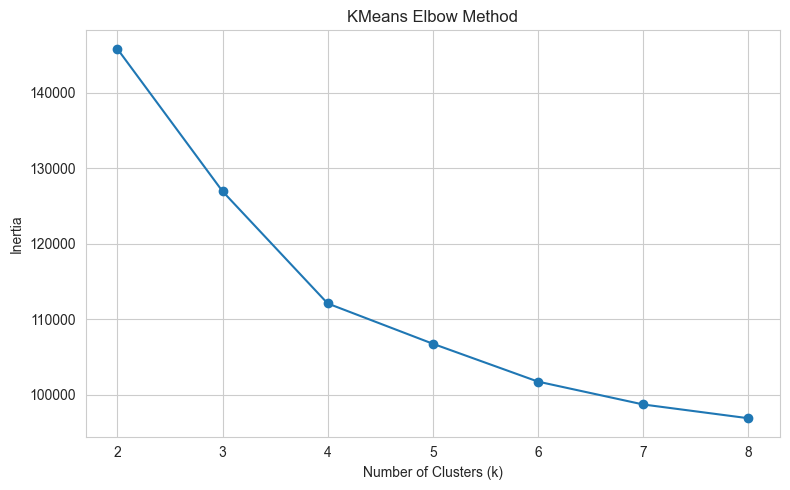

Saved: c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\kmeans_elbow_method.png


In [9]:
elbow_path = results_dir / 'kmeans_elbow_method.png'

plt.figure()
plt.plot(cluster_eval_df['k'], cluster_eval_df['inertia'], marker='o')
plt.title('KMeans Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(cluster_eval_df['k'])
plt.tight_layout()
plt.savefig(elbow_path, dpi=300)
plt.show()

print(f'Saved: {elbow_path}')

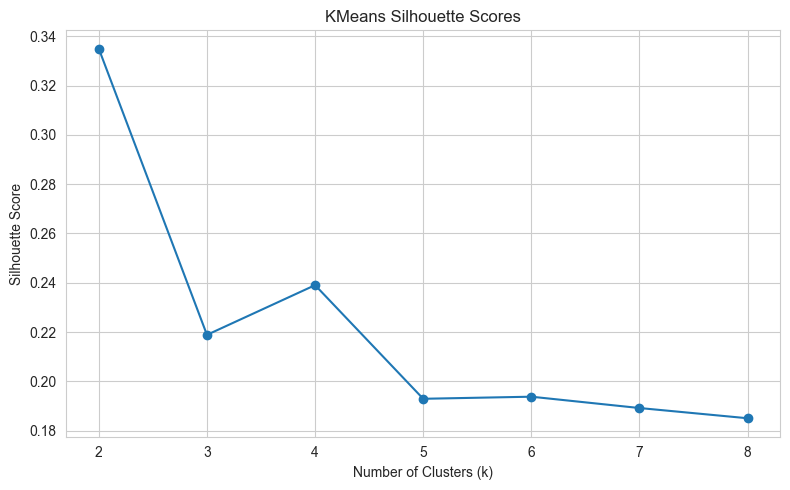

Saved: c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\kmeans_silhouette_scores.png


In [10]:
silhouette_path = results_dir / 'kmeans_silhouette_scores.png'

plt.figure()
plt.plot(cluster_eval_df['k'], cluster_eval_df['silhouette_score'], marker='o')
plt.title('KMeans Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(cluster_eval_df['k'])
plt.tight_layout()
plt.savefig(silhouette_path, dpi=300)
plt.show()

print(f'Saved: {silhouette_path}')

## 9. Select Best k and Train Final KMeans

Best `k` is selected using the highest silhouette score.

In [11]:
best_k = int(cluster_eval_df.loc[cluster_eval_df['silhouette_score'].idxmax(), 'k'])
print(f'Selected best_k (highest silhouette score): {best_k}')

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
final_clusters = final_kmeans.fit_predict(X_scaled)

Selected best_k (highest silhouette score): 2


## 10. Attach Cluster Labels and Churn

In [12]:
clustered_df = X.copy()
clustered_df['Cluster'] = final_clusters

if pd.api.types.is_numeric_dtype(y):
    churn_numeric = y.astype(int)
else:
    y_str = y.astype(str).str.strip().str.lower()
    churn_map = {
        'yes': 1, 'no': 0,
        'true': 1, 'false': 0,
        '1': 1, '0': 0
    }
    churn_numeric = y_str.map(churn_map)

    if churn_numeric.isna().any():
        unique_vals = sorted(y_str.unique())
        raise ValueError(f'Unrecognized churn labels for mapping to 1/0: {unique_vals}')

clustered_df['Churn'] = churn_numeric.values
clustered_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Cluster,Churn
0,0,-1.114563,0.513107,-0.836255,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
1,1,-1.196004,0.734126,-0.908300,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,1
2,0,-1.196004,0.345265,-0.910153,0,1,0,1,0,1,...,0,0,0,0,1,1,0,0,0,1
3,0,1.125057,0.524739,1.132656,0,0,0,1,0,1,...,0,1,1,0,0,1,0,0,0,0
4,0,-0.829521,1.134619,-0.511236,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,1


## 11. Cluster Summary Table

In [13]:
agg_dict = {'Churn': ['count', 'sum', 'mean']}

optional_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in optional_cols:
    if col in clustered_df.columns:
        agg_dict[col] = 'mean'

summary = clustered_df.groupby('Cluster').agg(agg_dict)
summary.columns = ['_'.join(c).strip('_') if isinstance(c, tuple) else c for c in summary.columns.values]
summary = summary.reset_index()

rename_map = {
    'Churn_count': 'Customer_Count',
    'Churn_sum': 'Churn_Count',
    'Churn_mean': 'Churn_Rate',
    'tenure_mean': 'Average_tenure',
    'MonthlyCharges_mean': 'Average_MonthlyCharges',
    'TotalCharges_mean': 'Average_TotalCharges'
}
summary = summary.rename(columns=rename_map)

preferred_order = [
    'Cluster', 'Customer_Count', 'Churn_Count', 'Churn_Rate',
    'Average_tenure', 'Average_MonthlyCharges', 'Average_TotalCharges'
]
summary = summary[[c for c in preferred_order if c in summary.columns]]
summary = summary.sort_values('Cluster').reset_index(drop=True)
summary

,Cluster,Customer_Count,Churn_Count,Churn_Rate,Average_tenure,Average_MonthlyCharges,Average_TotalCharges
0,0,5517,1756,0.318289,0.020544,0.401575,0.19734
1,1,1526,113,0.074050,-0.074273,-1.451829,-0.71345


In [14]:
cluster_summary_csv = results_dir / 'customer_cluster_summary.csv'
summary.to_csv(cluster_summary_csv, index=False)
print(f'Saved: {cluster_summary_csv}')

Saved: c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\customer_cluster_summary.csv


## 12. Churn Rate by Cluster

C:\Users\yazee\AppData\Local\Temp\ipykernel_3924\999772180.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Cluster', y='Churn_Rate', palette='Blues_d')


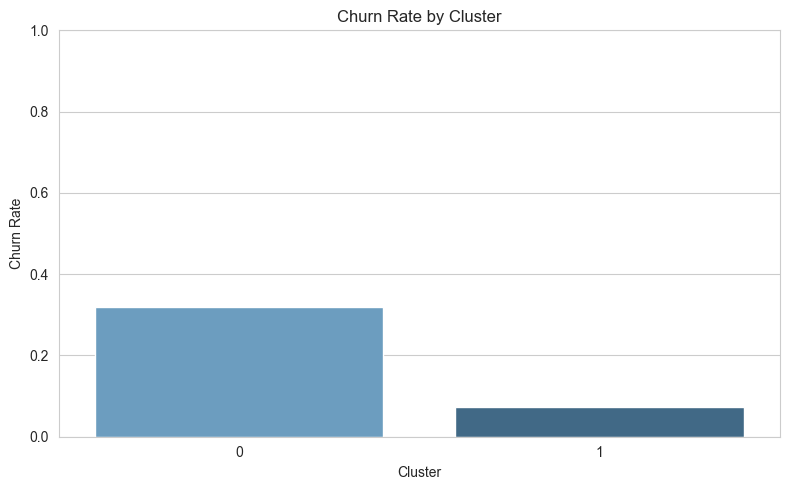

Saved: c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\churn_rate_by_cluster.png


In [15]:
churn_rate_plot_path = results_dir / 'churn_rate_by_cluster.png'

plot_df = summary[['Cluster', 'Churn_Rate']].copy()

plt.figure()
sns.barplot(data=plot_df, x='Cluster', y='Churn_Rate', palette='Blues_d')
plt.title('Churn Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(churn_rate_plot_path, dpi=300)
plt.show()

print(f'Saved: {churn_rate_plot_path}')

## 13. PCA 2D Cluster Visualization

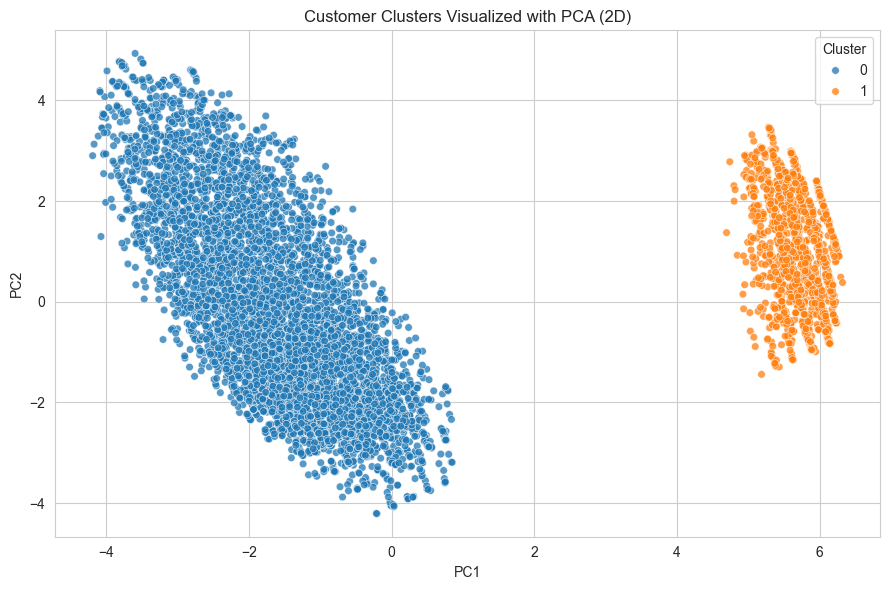

Saved: c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\customer_clusters_pca_2d.png


In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = final_clusters

pca_plot_path = results_dir / 'customer_clusters_pca_2d.png'

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.75, s=30)
plt.title('Customer Clusters Visualized with PCA (2D)')
plt.tight_layout()
plt.savefig(pca_plot_path, dpi=300)
plt.show()

print(f'Saved: {pca_plot_path}')

## 14. Discussion

- **How many clusters were selected and why?**
  - The selected number of clusters is `best_k`, chosen because it gives the **highest silhouette score** among `k=2..8`, indicating the best balance of compact and well-separated clusters in this search range.

- **Which cluster has the highest churn rate?**
  - Use the summary table sorted by `Churn_Rate` to identify the maximum value.

- **Which cluster has the lowest churn rate?**
  - Use the same summary table to identify the minimum `Churn_Rate`.

- **What customer characteristics appear in the high-churn cluster?**
  - Compare available averages (`tenure`, `MonthlyCharges`, `TotalCharges`) for the highest-churn cluster versus others to describe distinguishing patterns.

- **How can clustering help the business understand churn?**
  - Clustering highlights customer segments with similar behavior, helping teams target retention actions to specific group profiles rather than treating all customers the same.

- **Why clustering should not be compared directly with DTC/SVM classification accuracy?**
  - KMeans is unsupervised and does not optimize prediction against churn labels, while DTC/SVM are supervised models trained explicitly for churn prediction. Their objectives and evaluation criteria are fundamentally different.

## 15. Generated Files

In [17]:
generated_files = [
    results_dir / 'kmeans_cluster_evaluation.csv',
    results_dir / 'kmeans_elbow_method.png',
    results_dir / 'kmeans_silhouette_scores.png',
    results_dir / 'customer_cluster_summary.csv',
    results_dir / 'churn_rate_by_cluster.png',
    results_dir / 'customer_clusters_pca_2d.png'
]

print('Generated files:')
for f in generated_files:
    status = 'OK' if f.exists() else 'MISSING'
    print(f'- {f} [{status}]')

Generated files:
- c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\kmeans_cluster_evaluation.csv [OK]
- c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\kmeans_elbow_method.png [OK]
- c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\kmeans_silhouette_scores.png [OK]
- c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\customer_cluster_summary.csv [OK]
- c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\churn_rate_by_cluster.png [OK]
- c:\Users\yazee\OneDrive\Desktop\ML_Proj\results\customer_clusters_pca_2d.png [OK]
